# Análise e Gráficos Comparativos

Esse notebook contem os resultados dos dois notebooks de treino `01_Displasia_Nucleos` e `02_Tecido_Tumoral` numa tabela única com as 72 execuções, permitindo gerar e analisar a tabela resumo, gráficos de mDice/mIoU/parâmetros/GFLOPs, curvas de aprendizado em PDF e os mosaicos qualitativos de cada dataset.

In [1]:
!pip install -q segmentation-models-pytorch albumentations

import os
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.3 MB/s eta 0:00:00
Dispositivo em uso: cuda


#### Montagem do Drive e Definição dos Caminhos do Repositório

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/projeto 3/Repositorio'

# Displasia
DISPLASIA_DIR = os.path.join(BASE_DIR, 'datasets/oral_epithelium')
DISPLASIA_IMAGES_DIR = os.path.join(DISPLASIA_DIR, 'images/Original ROI images')
DISPLASIA_MASKS_DIR = os.path.join(DISPLASIA_DIR, 'masks/Gold_Standard_Semantic_Segmentation')
DISPLASIA_SPLITS_CSV = os.path.join(DISPLASIA_DIR, 'splits_displasia.csv')

# Tecido Tumoral
TUMORAL_DIR = os.path.join(BASE_DIR, 'datasets/tumor_tissue')
TUMORAL_SPLITS_CSV = os.path.join(TUMORAL_DIR, 'splits_tumoral.csv')

RESULTS_DIR = os.path.join(BASE_DIR, 'results')
CURVES_DIR = os.path.join(RESULTS_DIR, 'curves_json')
PLOTS_DIR = os.path.join(RESULTS_DIR, 'plots_pdf')
QUALITATIVE_DIR = os.path.join(RESULTS_DIR, 'qualitative')
CHECKPOINTS_DIR = os.path.join(BASE_DIR, 'checkpoints')

DISPLASIA_CSV = os.path.join(RESULTS_DIR, 'resultados_displasia.csv')
TUMORAL_CSV = os.path.join(RESULTS_DIR, 'resultados_tumoral.csv')
FINAL_CSV = os.path.join(RESULTS_DIR, 'resultados_consolidados.csv')
SUMMARY_CSV = os.path.join(RESULTS_DIR, 'tabela_resumo.csv')

CURVES_PLOTS_DIR = os.path.join(PLOTS_DIR, 'curvas_aprendizado')
os.makedirs(CURVES_PLOTS_DIR, exist_ok=True)
print('Diretórios verificados!')

Mounted at /content/drive
Diretórios verificados!


#### Configurações

In [3]:
INPUT_SIZE = 256
N_QUALITATIVE = 8
QUAL_SEED = 42

NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

#### Consolidação da Tabela Final

In [4]:
df_displasia = pd.read_csv(DISPLASIA_CSV)
df_tumoral = pd.read_csv(TUMORAL_CSV)

df_final = pd.concat([df_displasia, df_tumoral], ignore_index=True)
df_final.to_csv(FINAL_CSV, index=False)

print(f'Displasia: {len(df_displasia)} runs | Tumoral: {len(df_tumoral)} runs | Total: {len(df_final)} runs')

Displasia: 36 runs | Tumoral: 36 runs | Total: 72 runs


#### Tabela Resumo com Média e Desvio Padrão

In [5]:
summary = df_final.groupby(['dataset', 'model', 'training_mode', 'loss', 'augmentation']).agg(
    mDice_mean=('mDice_test', 'mean'),
    mDice_std=('mDice_test', 'std'),
    mIoU_mean=('mIoU_test', 'mean'),
    mIoU_std=('mIoU_test', 'std'),
    dice_fg_mean=('dice_foreground_test', 'mean'),
    dice_fg_std=('dice_foreground_test', 'std'),
    precision_fg_mean=('precision_foreground_test', 'mean'),
    precision_fg_std=('precision_foreground_test', 'std'),
    recall_fg_mean=('recall_foreground_test', 'mean'),
    recall_fg_std=('recall_foreground_test', 'std'),
    gflops=('gflops', 'first'),
    num_params=('num_params', 'first'),
    trainable_params=('trainable_params', 'first'),
).reset_index()

summary.to_csv(SUMMARY_CSV, index=False)
display(summary)

,dataset,model,training_mode,loss,augmentation,mDice_mean,mDice_std,mIoU_mean,mIoU_std,dice_fg_mean,dice_fg_std,precision_fg_mean,precision_fg_std,recall_fg_mean,recall_fg_std,gflops,num_params,trainable_params
0,displasia,sharp_unet,FS,bce,com_aug,0.815300,0.001758,0.695633,0.002060,0.737133,0.007015,0.761300,0.032619,0.716833,0.043391,27.492,7767361,7763041
1,displasia,sharp_unet,FS,bce,sem_aug,0.808833,0.005479,0.686267,0.007504,0.730833,0.007300,0.732467,0.013812,0.729433,0.011900,27.492,7767361,7763041
2,displasia,sharp_unet,FS,dice,com_aug,0.812533,0.008693,0.690733,0.012393,0.739233,0.008919,0.721733,0.027250,0.758333,0.012616,27.492,7767361,7763041
3,displasia,sharp_unet,FS,dice,sem_aug,0.802400,0.008381,0.678133,0.010706,0.719133,0.014636,0.737400,0.008815,0.702367,0.032005,27.492,7767361,7763041
4,displasia,unet_resnet18,FS,bce,com_aug,0.791900,0.004200,0.664733,0.005387,0.702200,0.006324,0.733833,0.006186,0.673233,0.009288,10.855,14328209,14328209
5,displasia,unet_resnet18,FS,bce,sem_aug,0.781500,0.000889,0.650867,0.001124,0.689133,0.001401,0.708933,0.003449,0.670467,0.004302,10.855,14328209,14328209
6,displasia,unet_resnet18,FS,dice,com_aug,0.797533,0.007594,0.670800,0.010410,0.716933,0.009506,0.707233,0.019258,0.727300,0.013896,10.855,14328209,14328209
7,displasia,unet_resnet18,FS,dice,sem_aug,0.782100,0.002722,0.651533,0.003347,0.690433,0.005006,0.707500,0.005651,0.674300,0.012486,10.855,14328209,14328209
8,displasia,unet_resnet18,PT-ALL,bce,com_aug,0.823400,0.004715,0.707467,0.006401,0.744733,0.007850,0.800267,0.001343,0.696567,0.014270,10.855,14328209,14328209
9,displasia,unet_resnet18,PT-ALL,bce,sem_aug,0.816100,0.002464,0.697467,0.003317,0.734367,0.004148,0.788067,0.010451,0.687767,0.011974,10.855,14328209,14328209


#### Gráfico de mDice por Configuração

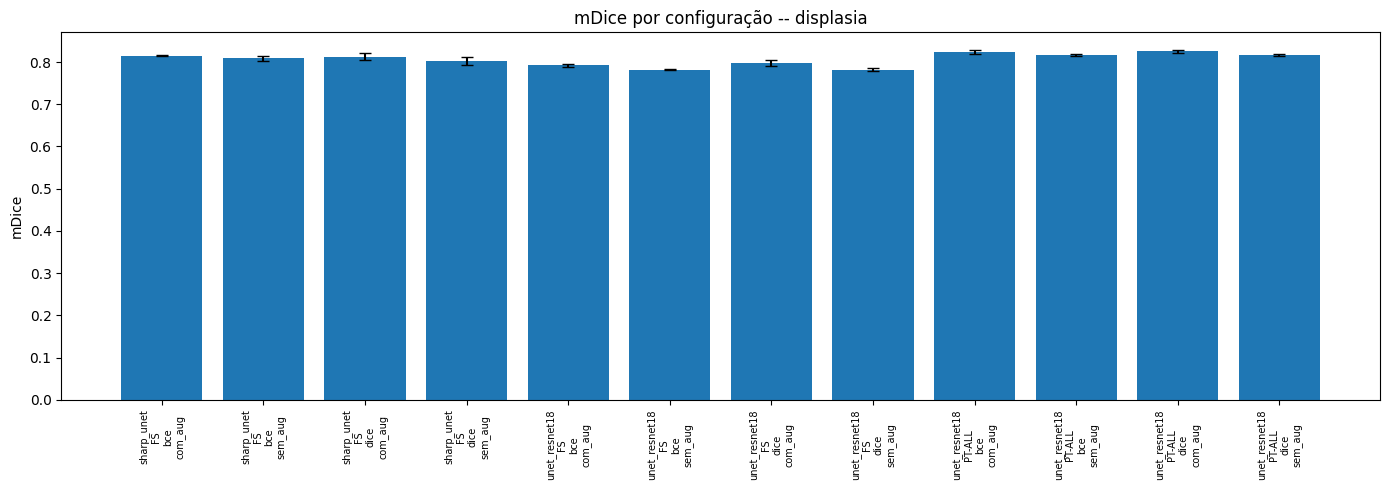

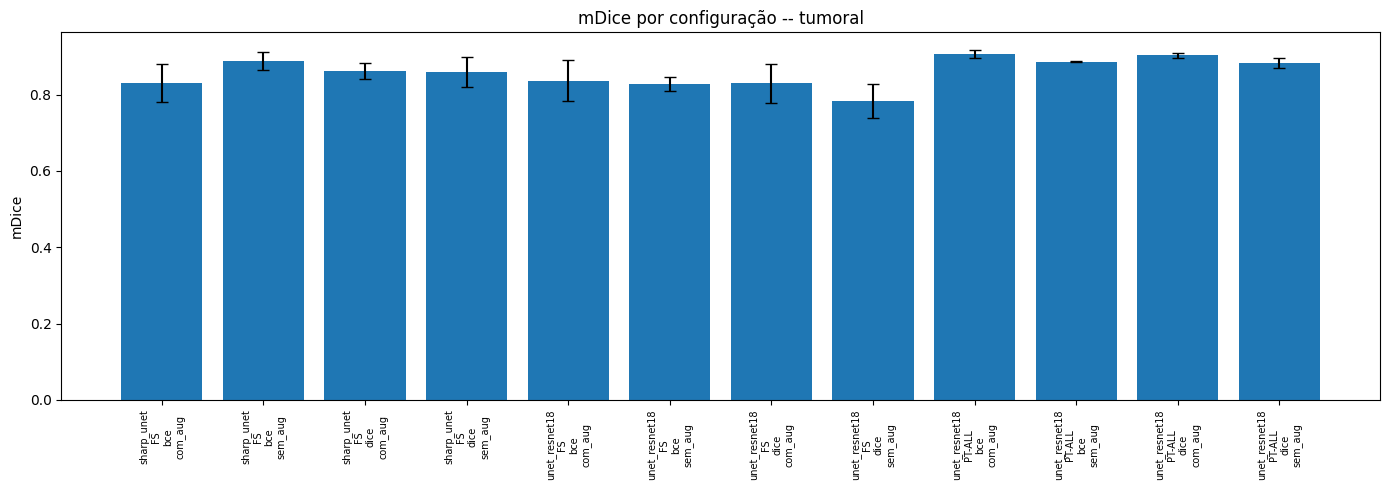

In [6]:
def plot_metric_bars(df, dataset_name, metric_mean_col, metric_std_col, ylabel, save_name):
    df_ds = df[df['dataset'] == dataset_name].copy()
    df_ds['config'] = df_ds['model'] + '\n' + df_ds['training_mode'] + '\n' + df_ds['loss'] + '\n' + df_ds['augmentation']
    df_ds = df_ds.sort_values('config')

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(df_ds['config'], df_ds[metric_mean_col], yerr=df_ds[metric_std_col], capsize=4)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} por configuração -- {dataset_name}')
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, save_name))
    plt.show()

for dataset_name in ['displasia', 'tumoral']:
    plot_metric_bars(summary, dataset_name, 'mDice_mean', 'mDice_std', 'mDice', f'mdice_{dataset_name}.pdf')

#### Gráfico de mIoU por Configuração

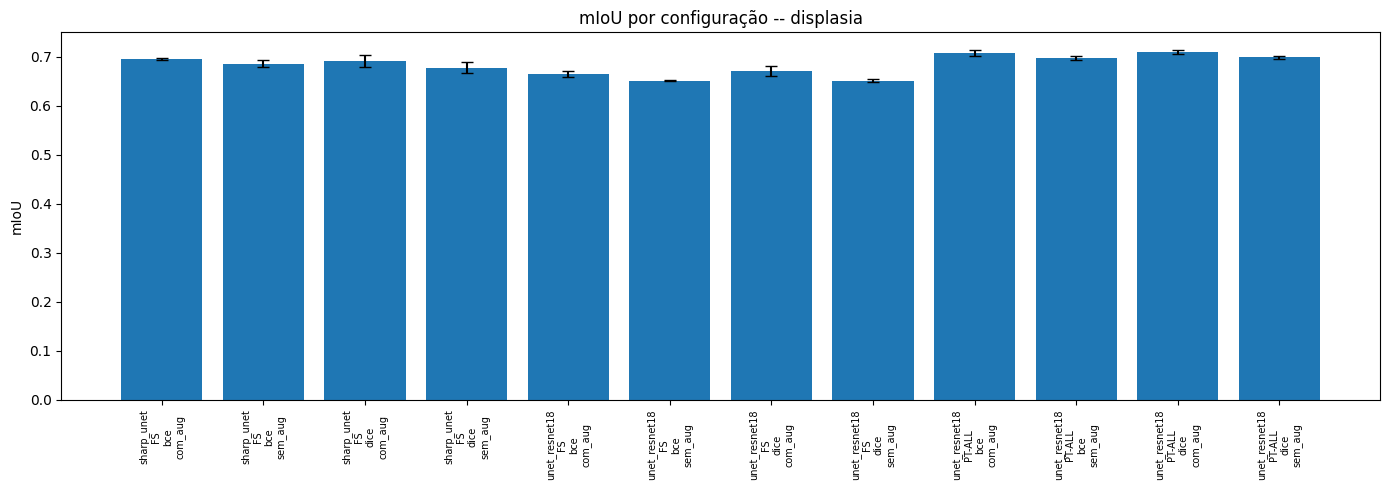

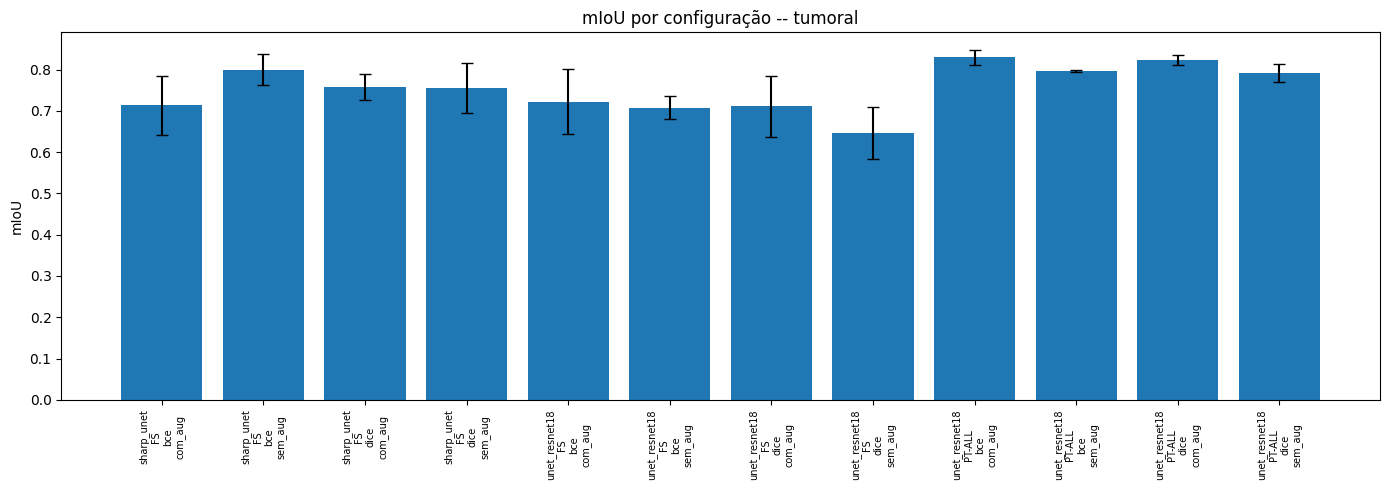

In [7]:
for dataset_name in ['displasia', 'tumoral']:
    plot_metric_bars(summary, dataset_name, 'mIoU_mean', 'mIoU_std', 'mIoU', f'miou_{dataset_name}.pdf')

#### Número de Parâmetros por Arquitetura

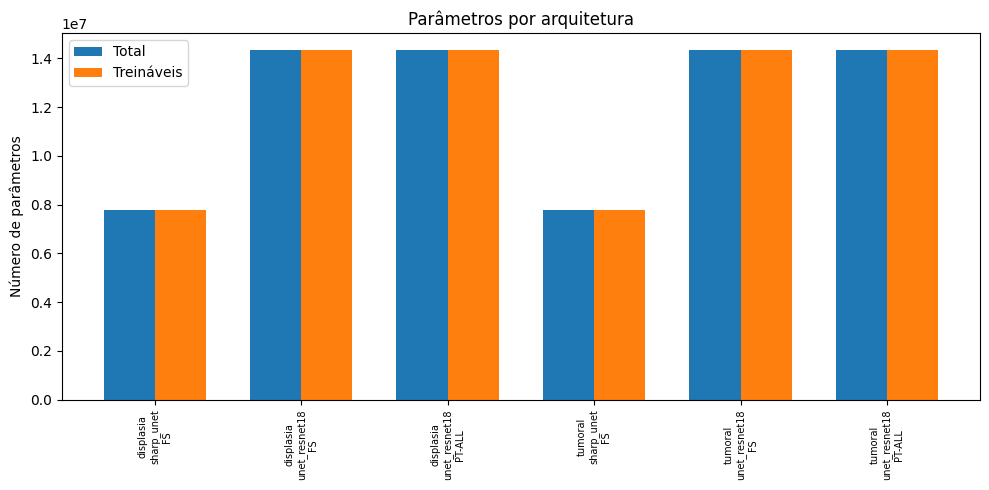

In [8]:
df_arch = df_final.drop_duplicates(subset=['dataset', 'model', 'training_mode'])
df_arch = df_arch.copy()
df_arch['config'] = df_arch['dataset'] + '\n' + df_arch['model'] + '\n' + df_arch['training_mode']
df_arch = df_arch.sort_values('config')

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
x = np.arange(len(df_arch))
ax.bar(x - width/2, df_arch['num_params'], width, label='Total')
ax.bar(x + width/2, df_arch['trainable_params'], width, label='Treináveis')
ax.set_xticks(x)
ax.set_xticklabels(df_arch['config'], rotation=90, fontsize=7)
ax.set_ylabel('Número de parâmetros')
ax.set_title('Parâmetros por arquitetura')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'num_parametros.pdf'))
plt.show()

#### Complexidade Computacional (GFLOPs)

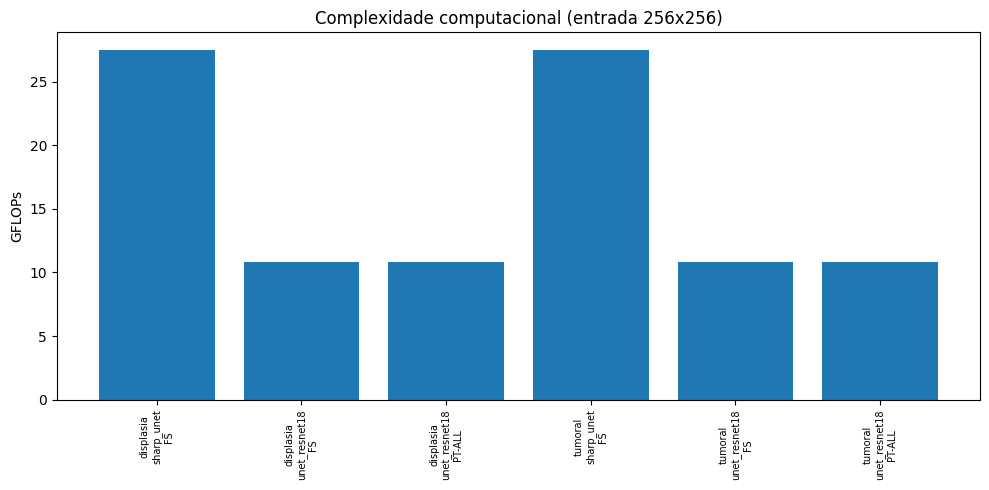

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_arch['config'], df_arch['gflops'])
ax.set_ylabel('GFLOPs')
ax.set_title(f'Complexidade computacional (entrada {INPUT_SIZE}x{INPUT_SIZE})')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gflops.pdf'))
plt.show()

#### Curvas de Aprendizado

In [10]:
curve_files = [f for f in os.listdir(CURVES_DIR) if f.endswith('.json')]
print(f'{len(curve_files)} curvas encontradas em {CURVES_DIR}')

for fname in curve_files:
    run_id = fname.replace('.json', '')
    with open(os.path.join(CURVES_DIR, fname)) as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history['train_loss'], label='Treino')
    axes[0].plot(epochs, history['val_loss'], label='Validação')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss por época')
    axes[0].legend()

    axes[1].plot(epochs, history['val_mDice'])
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('mDice (validação)')
    axes[1].set_title('mDice de validação por época')

    fig.suptitle(run_id, fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(CURVES_PLOTS_DIR, f'{run_id}.pdf'))
    plt.close(fig)

print('Curvas salvas em', CURVES_PLOTS_DIR)

72 curvas encontradas em /content/drive/MyDrive/projeto 3/Repositorio/results/curves_json
Curvas salvas em /content/drive/MyDrive/projeto 3/Repositorio/results/plots_pdf/curvas_aprendizado


#### Arquiteturas e Dataset Classes Pra Inferência

In [11]:
class SharpBlock(nn.Module):
    """
    Bloco de sharpening do Sharp U-Net (Zunair & Ben Hamza, 2021)
    """
    def __init__(self, in_channels):
        super(SharpBlock, self).__init__()
        # kernel Laplaciano de 8 vizinhos
        kernel = torch.tensor([[-1., -1., -1.],
                                [-1.,  8., -1.],
                                [-1., -1., -1.]], dtype=torch.float32)
        kernel = kernel.repeat(in_channels, 1, 1, 1)
        # nao é atualizado durante o treinamento
        self.weight = nn.Parameter(kernel, requires_grad=False)
        self.in_channels = in_channels

    def forward(self, x):
        # S = I + K * I
        conv_out = F.conv2d(x, self.weight, padding=1, groups=self.in_channels)
        return x + conv_out


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class SharpUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.sharp_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        curr_in = in_channels
        for feat in features:
            self.downs.append(ConvBlock(curr_in, feat))
            self.sharp_blocks.append(SharpBlock(feat))
            curr_in = feat

        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat * 2, feat, kernel_size=2, stride=2))
            self.ups.append(ConvBlock(feat * 2, feat))

        self.final_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for i, down in enumerate(self.downs):
            x = down(x)
            sharp_skip = self.sharp_blocks[i](x)
            skip_connections.append(sharp_skip)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])
            concat_x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](concat_x)

        return self.final_conv(x)


def build_model(model_name, training_mode, in_channels=3, num_classes=1):
    if model_name == 'sharp_unet':
        return SharpUNet(in_channels=in_channels, num_classes=num_classes)
    elif model_name == 'unet_resnet18':
        weights = 'imagenet' if training_mode == 'PT-ALL' else None
        return smp.Unet(
            encoder_name='resnet18',
            encoder_weights=weights,
            in_channels=in_channels,
            classes=num_classes
        )
    else:
        raise ValueError(f'Modelo desconhecido: {model_name}')


def get_eval_transform(img_size=INPUT_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ])


class DisplasiaEvalDataset(Dataset):
    def __init__(self, df, images_dir, masks_dir, transform):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        mask_path = os.path.join(self.masks_dir, row['mask'])
        image = np.array(Image.open(img_path).convert('RGB'), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L'), dtype=np.float32) > 0).astype(np.float32)
        raw_image = (image * 255).astype(np.uint8)
        augmented = self.transform(image=image, mask=mask)
        return augmented['image'], augmented['mask'].unsqueeze(0), raw_image


class TumoralEvalDataset(Dataset):
    def __init__(self, df, dataset_dir, transform):
        self.df = df.reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.dataset_dir, row['image'])
        mask_path = os.path.join(self.dataset_dir, row['mask'])
        image = np.array(Image.open(img_path).convert('RGB'), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L'), dtype=np.float32) >= 128).astype(np.float32)
        raw_image = (image * 255).astype(np.uint8)
        augmented = self.transform(image=image, mask=mask)
        return augmented['image'], augmented['mask'].unsqueeze(0), raw_image

#### Mosaicos Qualitativos

Pra cada dataset, pega a configuração com maior mDice de teste, carrega o checkpoint salvo e roda no conjunto de teste inteiro. As `N_QUALITATIVE` amostras do mosaico são escolhidas espalhadas entre o Dice por imagem dos melhores casos aos piores.

In [12]:
@torch.no_grad()
def generate_mosaic(dataset_name, eval_ds, df_final, checkpoints_dir, device, n_samples, save_path):
    best_row = df_final[df_final['dataset'] == dataset_name].sort_values('mDice_test', ascending=False).iloc[0]
    run_id = best_row['run_id']
    print(f'{dataset_name}: melhor config = {run_id} (mDice teste = {best_row["mDice_test"]:.4f})')

    model = build_model(best_row['model'], best_row['training_mode']).to(device)
    ckpt_path = os.path.join(checkpoints_dir, f'best_{run_id}.pth')
    state_dict = torch.load(ckpt_path, map_location=device)
    junk_keys = [k for k in state_dict if k.endswith('total_ops') or k.endswith('total_params')]
    if junk_keys:
        print(f'  (ignorando {len(junk_keys)} chaves de profiling do thop no checkpoint)')
        for k in junk_keys:
            state_dict.pop(k)
    model.load_state_dict(state_dict)
    model.eval()

    loader = DataLoader(eval_ds, batch_size=8, shuffle=False, num_workers=2)

    dice_scores, all_images, all_masks, all_preds = [], [], [], []
    for images, masks, raw_images in loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).cpu()
        preds = (probs >= 0.5).float()

        for i in range(images.size(0)):
            p, t = preds[i].view(-1), masks[i].view(-1)
            inter = (p * t).sum().item()
            dice = (2 * inter + 1e-6) / (p.sum().item() + t.sum().item() + 1e-6)
            dice_scores.append(dice)
            all_images.append(raw_images[i].numpy())
            all_masks.append(masks[i, 0].numpy())
            all_preds.append(preds[i, 0].numpy())

    order = np.argsort(dice_scores)
    idxs = order[np.linspace(0, len(order) - 1, n_samples).astype(int)]

    fig, axes = plt.subplots(n_samples, 4, figsize=(12, 3 * n_samples))
    col_titles = ['Imagem', 'Ground Truth', 'Predição', 'Overlay']
    for row_i, idx in enumerate(idxs):
        img, gt, pred = all_images[idx], all_masks[idx], all_preds[idx]

        axes[row_i, 0].imshow(img)
        axes[row_i, 1].imshow(gt, cmap='gray')
        axes[row_i, 2].imshow(pred, cmap='gray')
        axes[row_i, 3].imshow(img)
        axes[row_i, 3].imshow(pred, cmap='Reds', alpha=0.4)

        axes[row_i, 0].set_ylabel(f'Dice {dice_scores[idx]:.2f}', fontsize=8)
        for c in range(4):
            axes[row_i, c].set_xticks([])
            axes[row_i, c].set_yticks([])
            if row_i == 0:
                axes[row_i, c].set_title(col_titles[c], fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


eval_tf = get_eval_transform()

df_splits_displasia = pd.read_csv(DISPLASIA_SPLITS_CSV)
test_displasia = df_splits_displasia[df_splits_displasia['split'] == 'test']
ds_displasia = DisplasiaEvalDataset(test_displasia, DISPLASIA_IMAGES_DIR, DISPLASIA_MASKS_DIR, eval_tf)
generate_mosaic('displasia', ds_displasia, df_final, CHECKPOINTS_DIR, device, N_QUALITATIVE,
                 os.path.join(QUALITATIVE_DIR, 'mosaico_displasia.png'))

df_splits_tumoral = pd.read_csv(TUMORAL_SPLITS_CSV)
test_tumoral = df_splits_tumoral[df_splits_tumoral['split'] == 'test']
ds_tumoral = TumoralEvalDataset(test_tumoral, TUMORAL_DIR, eval_tf)
generate_mosaic('tumoral', ds_tumoral, df_final, CHECKPOINTS_DIR, device, N_QUALITATIVE,
                 os.path.join(QUALITATIVE_DIR, 'mosaico_tumoral.png'))

Output hidden; open in https://colab.research.google.com to view.